In [36]:
import pickle
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

sys.path.insert(0, str(Path.cwd().parent))
from viz_style import apply_style

import MixedEffectsModeling.config as config

# the sweep's own modules live beside its cache, not next to this notebook
sys.path.insert(0, str(config.METHOD_COMP_DIR))
from common import Q_LEVELS

apply_style()

CACHE = config.METHOD_COMP_CACHE_DIR
FIGDIR = config.METHOD_COMP_FIG_DIR
FIGDIR.mkdir(parents=True, exist_ok=True)

ARMS = ["engine", "autoencoder", "pca", "outsingle", "peer"]
LABELS = {"engine": "Normative engine", "autoencoder": "OUTRIDER (AE)", "pca": "PCA",
          "outsingle": "OutSingle", "peer": "PEER"}
COLORS = {"engine": "#000000", "autoencoder": "#1B9E77", "pca": "#7570B3",
          "outsingle": "#D95F02", "peer": "#E7298A"}
Q_MARKERS = {0.05: "o", 0.10: "s", 0.20: "^", 0.25: "D"}
# only the normative engine is solid; the baselines read as one dashed family
STYLES = {"engine": "-", "autoencoder": (0, (5, 2)), "pca": (0, (3, 1.5)),
          "outsingle": (0, (1.5, 1.5)), "peer": (0, (6, 1.5, 1.5, 1.5))}
SPLIT_TITLE = {"cv": "5-fold CV", "lobo": "leave-one-batch-out"}
LOG2FCS_SHOWN = [2.0, 3.0, 4.0]


In [37]:
D = pickle.loads((CACHE / "plot_data.pkl").read_bytes())
Q_GRID, RECALL_GRID = D["q_grid"], D["recall_grid"]
print(sorted({f for f, _ in D["cv"]["curves"]}), "log2FC levels cached")

[2.0, 3.0, 4.0, 5.0] log2FC levels cached


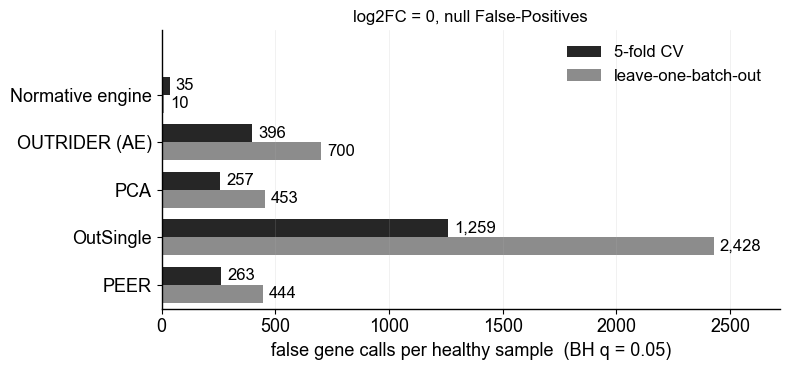

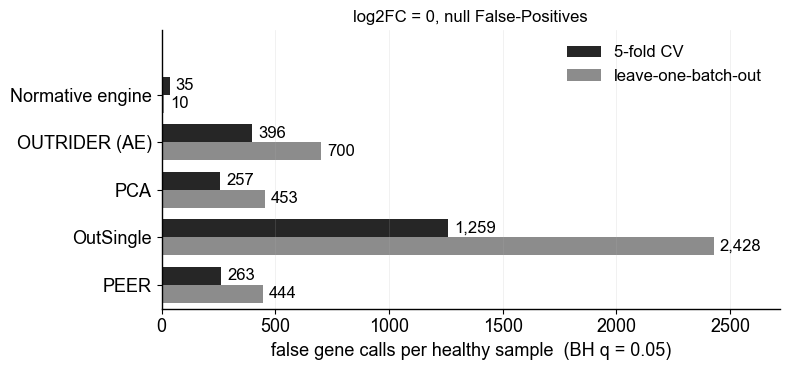

In [46]:
def null_falsecalls(q=0.05, save=True):
    n_genes = len((CACHE / "eval_universe_nm.txt").read_text().split())
    lg = np.log10(np.maximum(Q_GRID, 1e-12))
    rate = lambda sp, a: np.interp(np.log10(q), lg, D["null"][(sp, a)])
    fig, ax = plt.subplots(figsize=(8.0, 3.8))
    h = 0.38
    xmax = max(rate(sp, a) for sp in ("cv", "lobo") for a in ARMS) * n_genes * 1.12
    for k, split in enumerate(("cv", "lobo")):
        y = np.arange(len(ARMS)) + (k - 0.5) * h
        val = np.array([rate(split, a) * n_genes for a in ARMS])
        ax.barh(y, val, height=h, color="0.15" if split == "cv" else "0.55",
                edgecolor="none", label=SPLIT_TITLE[split])
        for yi, v in zip(y, val):
            ax.text(v + xmax * 0.01, yi, f"{v:,.0f}", va="center", fontsize=12)
    ax.set_xlim(0, xmax); ax.set_ylim(len(ARMS) - 0.5, -1.35)
    ax.set_yticks(range(len(ARMS))); ax.set_yticklabels([LABELS[a] for a in ARMS])
    ax.set_xlabel(f"false gene calls per healthy sample  (BH q = {q:g})")
    ax.grid(axis="x", alpha=0.25, lw=0.5)
    ax.legend(frameon=False, fontsize=12, loc="upper right", ncol=1, bbox_to_anchor=(0.995, 1.0))
    ax.set_title("log2FC = 0, null False-Positives", fontsize=12)
    fig.tight_layout()
    if save:
        fig.savefig(FIGDIR / "null_falsecalls.png", dpi=300, bbox_inches="tight")
    return fig

null_falsecalls()

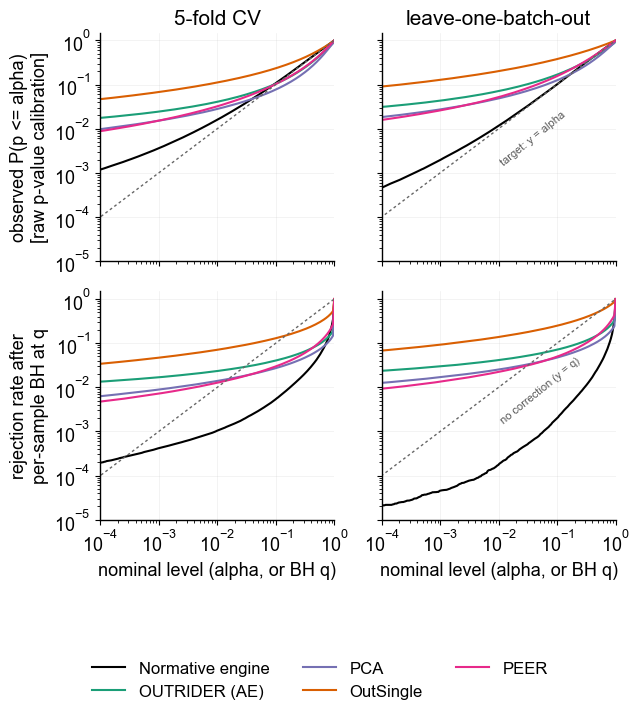

In [14]:
pcal, null = D["pcal"], D["null"]
fig, axes = plt.subplots(2, 2, figsize=(6.5, 6), sharex=True, sharey="row")
for j, split in enumerate(("cv", "lobo")):
    for arm in ARMS:
        axes[0, j].plot(Q_GRID, np.maximum(pcal[(split, arm)], 1e-6), color=COLORS[arm],
                        lw=1.5, label=LABELS[arm] if j == 0 else None)
        axes[1, j].plot(Q_GRID, np.maximum(null[(split, arm)], 1e-6), color=COLORS[arm], lw=1.5)
    for i in (0, 1):
        ax = axes[i, j]
        ax.plot(Q_GRID, Q_GRID, color="0.4", lw=1.0, ls=(0, (2, 2)))
        ax.set_xscale("log"); ax.set_yscale("log")
        ax.set_xlim(1e-4, 1); ax.set_ylim(1e-5, 1.5)
        ax.grid(alpha=0.2, lw=0.5)
    axes[0, j].set_title(SPLIT_TITLE[split])
    axes[1, j].set_xlabel("nominal level (alpha, or BH q)")
axes[0, 0].set_ylabel("observed P(p <= alpha)\n[raw p-value calibration]")
axes[1, 0].set_ylabel("rejection rate after\nper-sample BH at q")
axes[0, 1].text(0.50, 0.42, "target: y = alpha", color="0.35", fontsize=8,
                rotation=39, transform=axes[0, 1].transAxes)
axes[1, 1].text(0.50, 0.42, "no correction (y = q)", color="0.35", fontsize=8,
                rotation=39, transform=axes[1, 1].transAxes)
h, l = axes[0, 0].get_legend_handles_labels()
fig.legend(h, l, loc="lower center", ncol=3, frameon=False, fontsize=12,
           bbox_to_anchor=(0.5, -0.2))
fig.tight_layout()
fig.savefig(FIGDIR / "null_rejection.png", dpi=300, bbox_inches="tight")

In [15]:
# Inflation factor: observed / nominal. 1.0 = perfectly calibrated, >1 = anti-conservative.
import pandas as pd

alphas = [1e-4, 1e-3, 1e-2, 0.05]
idx = np.searchsorted(Q_GRID, alphas)
rows = {(SPLIT_TITLE[s], LABELS[a]): pcal[(s, a)][idx] / np.array(alphas)
        for s in ("cv", "lobo") for a in ARMS}
pd.DataFrame(rows, index=[f"alpha={a:g}" for a in alphas]).T.round(2)

alpha=0.0001  alpha=0.001  alpha=0.01  \
5-fold CV           Normative engine         11.93         3.66        1.63   
                    OUTRIDER (AE)           176.02        24.52        4.11   
                    PCA                      97.90        15.28        2.83   
                    OutSingle               467.69        68.04       11.23   
                    PEER                     88.26        15.33        3.26   
leave-one-batch-out Normative engine          4.65         1.99        1.20   
                    OUTRIDER (AE)           311.59        43.36        7.19   
                    PCA                     183.06        27.48        4.90   
                    OutSingle               901.66       128.35       20.31   
                    PEER                    158.37        26.11        5.26   

                                      alpha=0.05  
5-fold CV           Normative engine        1.20  
                    OUTRIDER (AE)           1.48  
                    PCA                     1.08  
                    OutSingle               3.64  
                    PEER                    1.38  
leave-one-batch-out Normative engine        1.06  
                    OUTRIDER (AE)           2.49  
                    PCA                     1.80  
                    OutSingle               6.18  
                    PEER                    2.15

In [34]:
def pr_grid(log2fcs=LOG2FCS_SHOWN, splits=("cv", "lobo"), arms=ARMS, band=True, save=True):
    """Line = per-fold median, ribbon = fold IQR, markers = the reported BH levels placed at
    the median recall reached there and read off the curve, so they sit ON the line."""
    fig, axes = plt.subplots(len(log2fcs), len(splits),
                             figsize=(2.7* len(splits), 2.4 * len(log2fcs)),
                             sharex=True, sharey=True, squeeze=False)
    for i, f in enumerate(log2fcs):
        for j, split in enumerate(splits):
            ax = axes[i, j]
            bands, ops = D[split]["bands"], D[split]["ops"]
            for arm in arms:
                lo, med, hi = bands[(f, arm)]
                if band:
                    ax.fill_between(RECALL_GRID, lo, hi, color=COLORS[arm], alpha=0.15, lw=0)
                ax.plot(RECALL_GRID, med, color=COLORS[arm], ls=STYLES[arm],
                        lw=2.0 if arm == "engine" else 1.4,
                        label=LABELS[arm] if (i, j) == (0, 0) else None,
                        zorder=4 if arm == "engine" else 3)
                for q in Q_LEVELS:
                    r = ops[("med", q, f, arm)][0]
                    ax.plot(r, np.interp(r, RECALL_GRID, med), marker=Q_MARKERS[q], ms=4,
                            color=COLORS[arm], mec="white", mew=0.6, ls="none", zorder=5)
            ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
            ax.grid(alpha=0.2, lw=0.5)
            if i == 0:
                ax.set_title(SPLIT_TITLE[split])
            if j == len(splits) - 1:
                ax.text(1.06, 0.5, f"log2FC = {f:g}", rotation=270, va="center",
                        ha="left", fontsize=12, transform=ax.transAxes,
                        bbox=dict(facecolor="0.92", edgecolor="none", pad=3))
            if j == 0:
                ax.set_ylabel("Precision")
            if i == len(log2fcs) - 1:
                ax.set_xlabel("Recall")
    h, l = axes[0, 0].get_legend_handles_labels()
    leg = fig.legend(h, l, loc="upper left", bbox_to_anchor=(1.02, 0.95), frameon=False,
                     fontsize=12, title="Method")
    leg.get_title().set_fontsize(12)
    qh = [plt.Line2D([], [], marker=m, ls="none", color="0.3", ms=4, mec="white", mew=0.6)
          for m in Q_MARKERS.values()]
    leg2 = fig.legend(qh, [str(q) for q in Q_MARKERS], loc="upper left",
                      bbox_to_anchor=(1.02, 0.55), frameon=False, fontsize=12, title="BH q")
    leg2.get_title().set_fontsize(12)
    fig.tight_layout()
    if save:
        fig.savefig(FIGDIR / "pr_grid.png", dpi=300, bbox_inches="tight")
    return fig

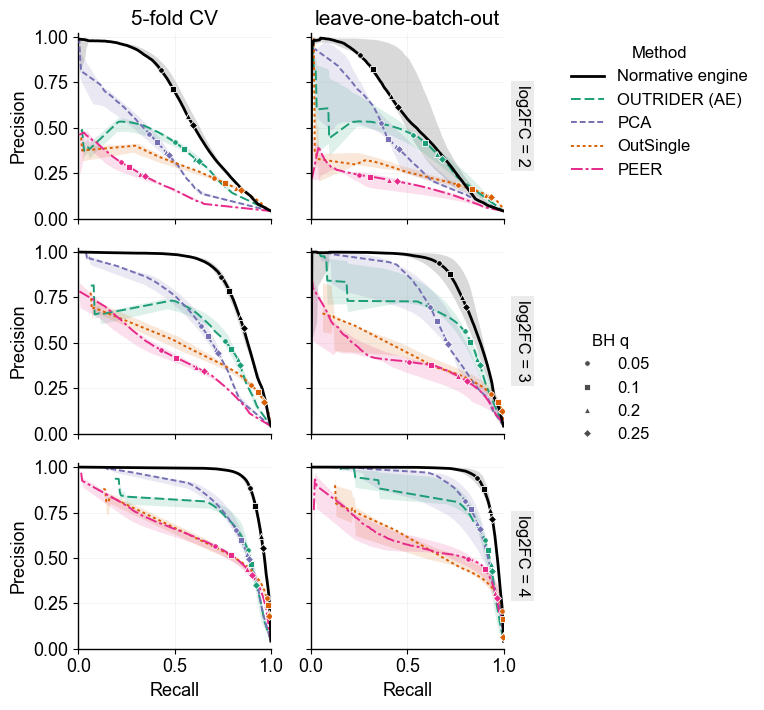

In [35]:
pr_grid();